In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import entropy

def analyze_nir_channels(image_path):
    # 1. Cargar imagen
    img = cv2.imread(image_path)
    if img is None:
        print(f"Error: No se pudo cargar la imagen en {image_path}")
        return

    # La imagen viene en BGR por defecto en OpenCV
    b, g, r = cv2.split(img)
    channels = {'Blue': b, 'Green': g, 'Red': r}
    
    results = {}

    print(f"{'Canal':<10} | {'Media':<10} | {'Std Dev':<10} | {'Entropía':<10} | {'Rango (5-95%)':<15}")
    print("-" * 65)

    best_channel_name = None
    max_score = -1

    # 2. Análisis Estadístico por canal
    for name, channel_data in channels.items():
        # Aplanar array para cálculos
        flat_data = channel_data.flatten()
        
        # Métricas
        mu = np.mean(flat_data)           # Brillo promedio
        sigma = np.std(flat_data)         # Contraste (mientras más alto, mejor diferenciación)
        
        # Entropía de Shannon (Información contenida)
        # Calculamos el histograma para obtener probabilidades
        counts, _ = np.histogram(flat_data, bins=256, range=(0, 256))
        probs = counts / len(flat_data)
        ent = entropy(probs, base=2)
        
        # Rango dinámico efectivo (evitando outliers de ruido puro)
        p5 = np.percentile(flat_data, 5)
        p95 = np.percentile(flat_data, 95)
        dynamic_range = p95 - p5

        results[name] = channel_data

        print(f"{name:<10} | {mu:<10.2f} | {sigma:<10.2f} | {ent:<10.4f} | {dynamic_range:<15.1f}")

        # Heurística simple para elegir el mejor:
        # Priorizamos Desviación Estándar (contraste) y Entropía.
        # Score = Sigma * Entropía
        score = sigma * ent
        
        if score > max_score:
            max_score = score
            best_channel_name = name

    print("-" * 65)
    print(f"CONCLUSION: El canal recomendado es el **{best_channel_name}**")
    print(f"(Basado en la combinación de contraste y cantidad de información)")

    # 3. Visualización Técnica
    plt.figure(figsize=(12, 8))
    
    # Mostrar imagen original (se verá rara/magenta porque matplotlib usa RGB)
    plt.subplot(2, 2, 1)
    # Convertimos BGR a RGB solo para display
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title("Original (NIR falso color)")
    plt.axis('off')

    # Mostrar los 3 canales en escala de grises
    positions = {'Blue': 2, 'Green': 3, 'Red': 4}
    for name, data in channels.items():
        plt.subplot(2, 2, positions[name])
        plt.imshow(data, cmap='gray')
        
        # Si es el ganador, lo marcamos en el título
        title = f"Canal {name}"
        if name == best_channel_name:
            title += " (GANADOR)"
            # Guardamos este canal como la imagen final procesada
            cv2.imwrite(f"nir_processed_{name}.png", data)
            
        plt.title(title)
        plt.axis('off')

    plt.tight_layout()
    plt.show()

Canal      | Media      | Std Dev    | Entropía   | Rango (5-95%)  
-----------------------------------------------------------------
Blue       | 111.73     | 93.29      | 7.0436     | 233.0          
Green      | 0.83       | 2.90       | 1.7613     | 3.0            
Red        | 127.52     | 94.35      | 6.7521     | 226.0          
-----------------------------------------------------------------
CONCLUSION: El canal recomendado es el **Blue**
(Basado en la combinación de contraste y cantidad de información)


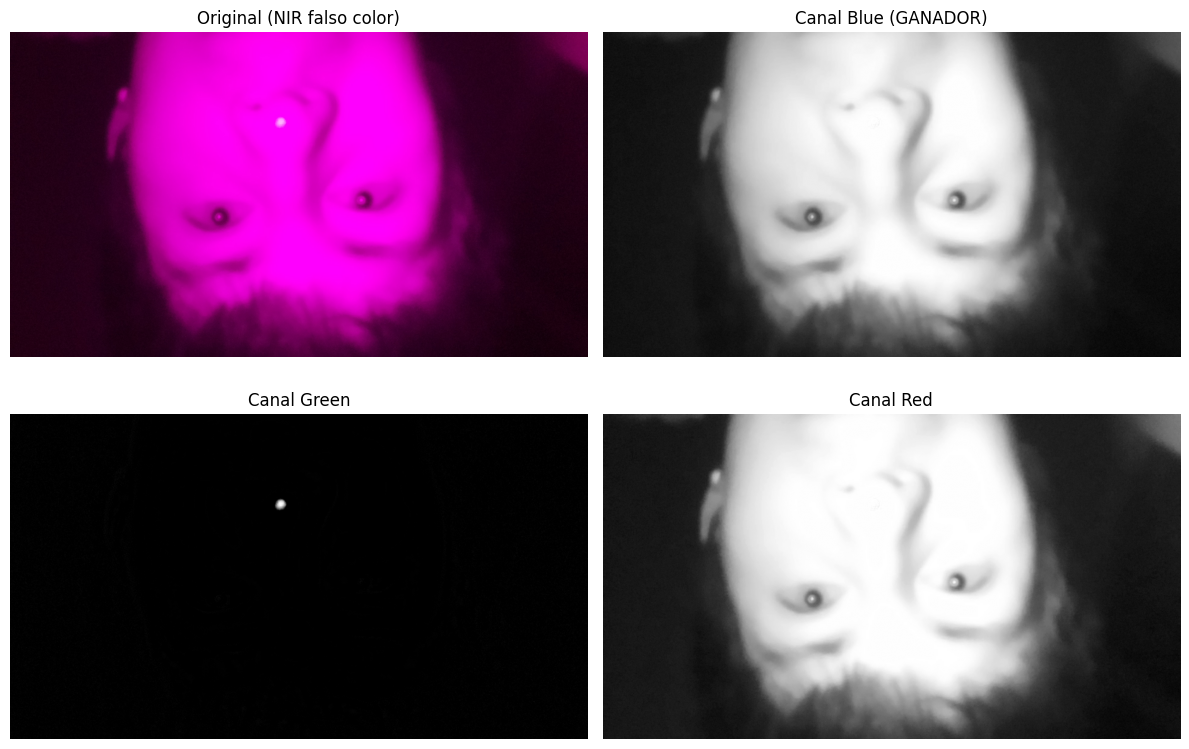

In [ ]:
# --- EJECUCIÓN ---
# Cambia 'tu_foto.jpg' por el nombre de tu archivo
analyze_nir_channels('images/news_nir_mango_nir_1766800423.jpg')